# Brain Tumor Detection using MRI Images - Complete PyTorch Pipeline

## Table of Contents
1. [Project Overview](#overview)
2. [Setup and Dependencies](#setup)
3. [Data Loading and Exploration](#data-exploration)
4. [Data Preprocessing and Augmentation](#preprocessing)
5. [Model Architecture Design](#model-architecture)
   - 5.1 Custom CNN Model
   - 5.2 Transfer Learning with VGG16
   - 5.3 Transfer Learning with ResNet50
6. [Model Training and Validation](#training)
7. [Model Evaluation and Comparison](#evaluation)
8. [Visualization and ROC Analysis](#visualization)
9. [Model Deployment Preparation](#deployment)
10. [Conclusion and Recommendations](#conclusion)

## 1. Project Overview <a id="overview"></a>

### Problem Statement
This project addresses the critical medical challenge of detecting brain tumors from MRI images. The goal is to develop an automated system that classifies MRI scans into two categories: **tumor present (yes)** or **no tumor (no)**.

### Dataset Description
- **Source**: [Kaggle - Navoneel Brain MRI Images for Brain Tumor Detection](https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection/data)
- **Size**: 253 MRI images
- **Classes**: 
  - **yes**: 155 images (tumor present)
  - **no**: 98 images (no tumor)
- **Format**: JPEG images of various dimensions

### Approach
1. **Data Preprocessing**: Image resizing, normalization, and augmentation
2. **Model Development**: 
   - Custom CNN from scratch
   - Transfer learning with VGG16
   - Transfer learning with ResNet50
3. **Evaluation**: Accuracy, precision, recall, F1, ROC-AUC
4. **Deployment Preparation**: TorchScript export, inference pipeline

### Expected Outcomes
- Automated tumor detection with >90% accuracy
- Production-ready PyTorch models

## 2. Setup and Dependencies <a id="setup"></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
import torchvision.transforms as transforms
from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                            roc_curve, auc, accuracy_score,
                            precision_score, recall_score, f1_score)

# 随机种子
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

# 设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 绘图风格
plt.style.use('fivethirtyeight')
sns.set_palette("husl")
%matplotlib inline

Using device: cpu


## 3. Data Loading and Exploration <a id="data-exploration"></a>

In [2]:
BASE_DIR = './brain_tumor_dataset'
YES_DIR = os.path.join(BASE_DIR, 'yes')
NO_DIR = os.path.join(BASE_DIR, 'no')

yes_count = len(os.listdir(YES_DIR))
no_count = len(os.listdir(NO_DIR))
total = yes_count + no_count

print(f"Tumor Present (yes): {yes_count}")
print(f"No Tumor (no): {no_count}")
print(f"Total: {total}")
print(f"Class Ratio: {yes_count/no_count:.2f}:1")

# 构建 DataFrame 记录路径和标签
filepaths = []
labels = []
for f in os.listdir(YES_DIR):
    if f.lower().endswith(('.jpg','.jpeg','.png')):
        filepaths.append(os.path.join(YES_DIR, f))
        labels.append(1)
for f in os.listdir(NO_DIR):
    if f.lower().endswith(('.jpg','.jpeg','.png')):
        filepaths.append(os.path.join(NO_DIR, f))
        labels.append(0)

df = pd.DataFrame({'filepath': filepaths, 'label': labels})
print(df.head())

Tumor Present (yes): 155
No Tumor (no): 98
Total: 253
Class Ratio: 1.58:1
                             filepath  label
0  ./brain_tumor_dataset/yes/Y157.JPG      1
1    ./brain_tumor_dataset/yes/Y6.jpg      1
2  ./brain_tumor_dataset/yes/Y194.jpg      1
3  ./brain_tumor_dataset/yes/Y180.jpg      1
4   ./brain_tumor_dataset/yes/Y90.jpg      1


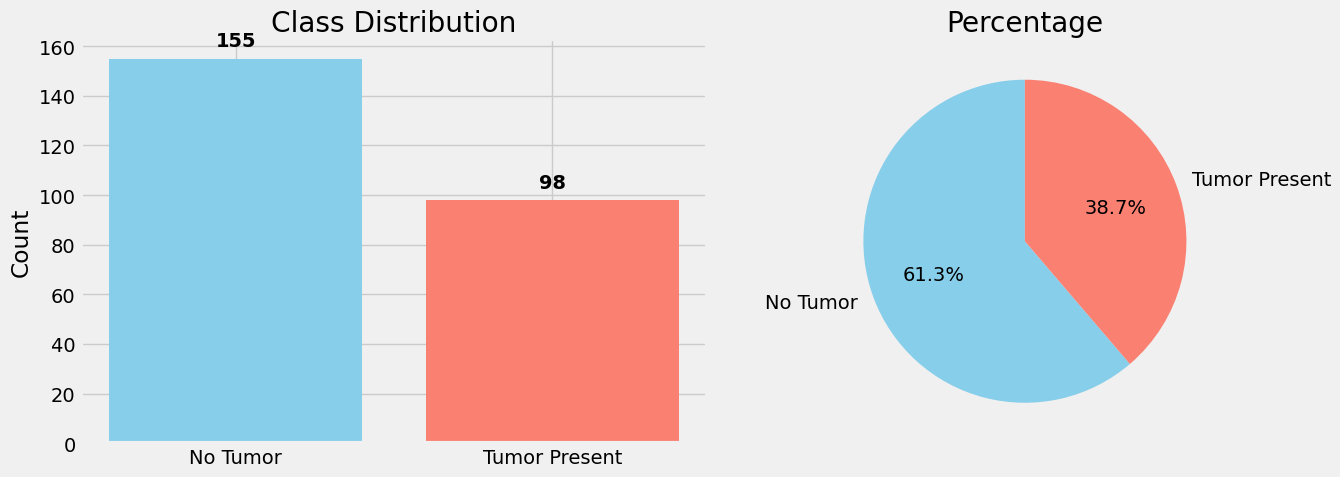

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
counts = df['label'].value_counts()
axes[0].bar(['No Tumor','Tumor Present'], counts.values, color=['skyblue','salmon'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['No Tumor','Tumor Present'],
            colors=['skyblue','salmon'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Percentage')
plt.tight_layout()
plt.show()

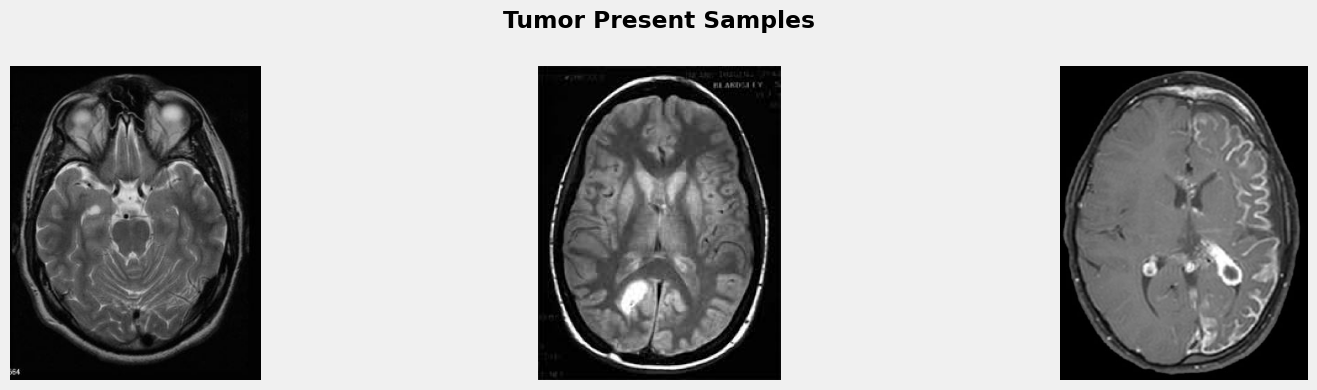

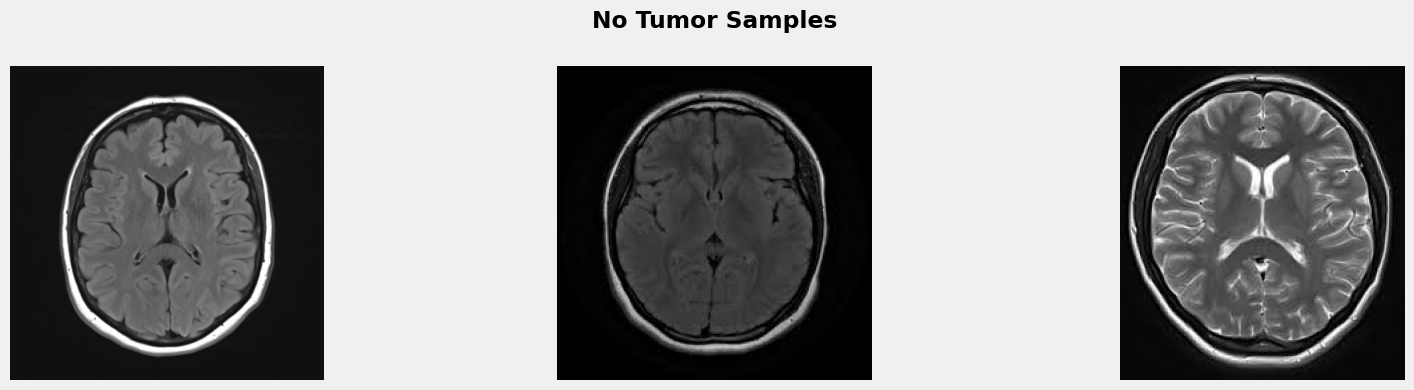

In [19]:
def show_samples(df, label, n=3):
    subset = df[df['label']==label].sample(n=min(n, len(df[df['label']==label])), random_state=42)
    fig, axes = plt.subplots(1, n, figsize=(18,4))
    if n==1: axes = [axes]
    name = 'Tumor Present' if label==1 else 'No Tumor'
    fig.suptitle(f'{name} Samples', fontweight='bold')
    for i, row in enumerate(subset.itertuples()):
        img = cv2.imread(row.filepath)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i].imshow(img)
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

show_samples(df, 1)
show_samples(df, 0)

## 4. Data Preprocessing and Augmentation <a id="preprocessing"></a>

We split the data into training and validation sets (80/20), then apply PyTorch transforms:
- Training: resize, random flip, slight rotation, color jitter, normalization
- Validation: resize and normalization only

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32

# 划分训练集和验证集
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=SEED)
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

# 自定义 Dataset
class BrainMRIDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe
        self.transform = transform
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = row['label']
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.float32)

# 训练和验证的 transformers
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 创建 DataLoader
train_dataset = BrainMRIDataset(train_df, transform=train_transform)
val_dataset = BrainMRIDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 显示一批数据
images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}, Labels: {labels[:5]}")

Train: 202, Val: 51
Batch shape: torch.Size([32, 3, 224, 224]), Labels: tensor([1., 0., 1., 1., 1.])


## 5. Model Architecture Design <a id="model-architecture"></a>

### 5.1 Custom CNN Model <a id="custom-cnn"></a>

In [8]:
class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # block1
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # block2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # block3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # block4
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25)
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

custom_model = CustomCNN().to(device)
print(custom_model)

CustomCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### 5.2 Transfer Learning with VGG16 <a id="transfer-learning-vgg16"></a>

In [9]:
def build_vgg16():
    model = models.vgg16(pretrained=True)
    for param in model.features.parameters():
        param.requires_grad = False
    model.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(25088, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(256, 1)
    )
    return model.to(device)

vgg_model = build_vgg16()
print(vgg_model)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

### 5.3 Transfer Learning with ResNet50 <a id="transfer-learning-resnet50"></a>

In [10]:
def build_resnet50():
    model = models.resnet50(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Sequential(
        nn.Linear(2048, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(512, 256), nn.ReLU(inplace=True), nn.Dropout(0.5),
        nn.Linear(256, 1)
    )
    return model.to(device)

resnet_model = build_resnet50()
print(resnet_model)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /Users/jasonzhang/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [01:19<00:00, 1.28MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## 6. Model Training and Validation <a id="training"></a>

We use binary cross-entropy with logits, Adam optimizer, LR scheduler, and early stopping.

In [11]:
def train_model(model, train_loader, val_loader, model_name, epochs=50, patience=10):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.2, patience=5, min_lr=1e-7)
    
    history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}
    best_val_loss = np.inf
    wait = 0
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, correct = 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device).unsqueeze(1)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * images.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).float()
            correct += (preds == labels).sum().item()
        
        train_loss /= len(train_loader.dataset)
        train_acc = correct / len(train_loader.dataset)
        
        # Validation
        model.eval()
        val_loss, correct = 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).unsqueeze(1)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                preds = (torch.sigmoid(outputs) >= 0.5).float()
                correct += (preds == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)
        
        scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        
        # Early stopping and save best
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), f'{model_name}_best.pt')
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered!")
                break
    
    # 加载最佳模型
    model.load_state_dict(torch.load(f'{model_name}_best.pt'))
    return model, history

In [12]:
print("Training Custom CNN...")
custom_model, custom_hist = train_model(custom_model, train_loader, val_loader, 'custom_cnn', epochs=50)

print("\nTraining VGG16...")
vgg_model, vgg_hist = train_model(vgg_model, train_loader, val_loader, 'vgg16', epochs=50)

print("\nTraining ResNet50...")
resnet_model, resnet_hist = train_model(resnet_model, train_loader, val_loader, 'resnet50', epochs=50)

Training Custom CNN...
Epoch 1/50 | Train Loss: 0.7467 Acc: 0.5000 | Val Loss: 0.6998 Acc: 0.3922
Epoch 2/50 | Train Loss: 0.6495 Acc: 0.6287 | Val Loss: 0.7371 Acc: 0.3725
Epoch 3/50 | Train Loss: 0.6216 Acc: 0.6832 | Val Loss: 0.6626 Acc: 0.5686
Epoch 4/50 | Train Loss: 0.6045 Acc: 0.7030 | Val Loss: 0.6492 Acc: 0.6667
Epoch 5/50 | Train Loss: 0.5670 Acc: 0.6980 | Val Loss: 0.5866 Acc: 0.7647
Epoch 6/50 | Train Loss: 0.6055 Acc: 0.6634 | Val Loss: 0.5992 Acc: 0.6471
Epoch 7/50 | Train Loss: 0.5671 Acc: 0.7079 | Val Loss: 0.5827 Acc: 0.7255
Epoch 8/50 | Train Loss: 0.5601 Acc: 0.7525 | Val Loss: 0.5343 Acc: 0.7647
Epoch 9/50 | Train Loss: 0.5409 Acc: 0.7277 | Val Loss: 0.5136 Acc: 0.7059
Epoch 10/50 | Train Loss: 0.5233 Acc: 0.7624 | Val Loss: 0.5311 Acc: 0.7255
Epoch 11/50 | Train Loss: 0.5462 Acc: 0.7574 | Val Loss: 0.5424 Acc: 0.6863
Epoch 12/50 | Train Loss: 0.5424 Acc: 0.7426 | Val Loss: 0.6504 Acc: 0.6667
Epoch 13/50 | Train Loss: 0.4789 Acc: 0.7426 | Val Loss: 0.5762 Acc: 0.725

## 7. Model Evaluation and Comparison <a id="evaluation"></a>


Custom CNN Results:
Accuracy: 0.7059, Precision: 0.7222, Recall: 0.8387, F1: 0.7761, AUC: 0.8258
               precision    recall  f1-score   support

     No Tumor       0.67      0.50      0.57        20
Tumor Present       0.72      0.84      0.78        31

     accuracy                           0.71        51
    macro avg       0.69      0.67      0.67        51
 weighted avg       0.70      0.71      0.70        51



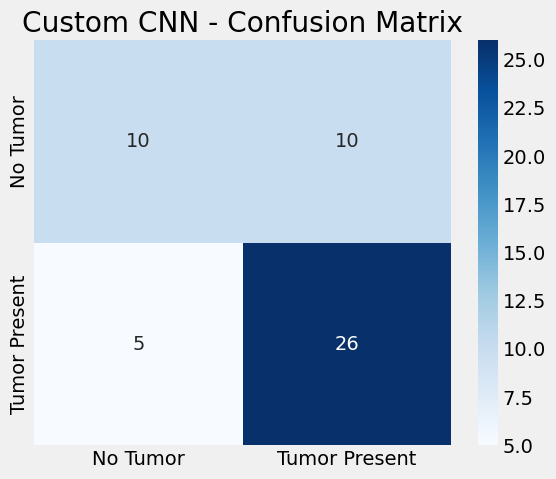


VGG16 Results:
Accuracy: 0.8627, Precision: 0.8529, Recall: 0.9355, F1: 0.8923, AUC: 0.8774
               precision    recall  f1-score   support

     No Tumor       0.88      0.75      0.81        20
Tumor Present       0.85      0.94      0.89        31

     accuracy                           0.86        51
    macro avg       0.87      0.84      0.85        51
 weighted avg       0.86      0.86      0.86        51



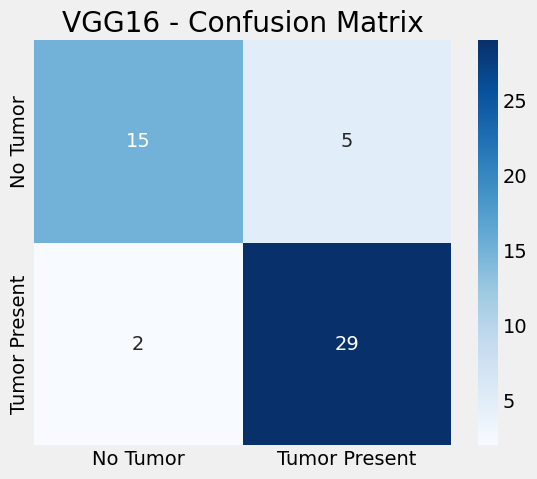


ResNet50 Results:
Accuracy: 0.9020, Precision: 0.8824, Recall: 0.9677, F1: 0.9231, AUC: 0.9339
               precision    recall  f1-score   support

     No Tumor       0.94      0.80      0.86        20
Tumor Present       0.88      0.97      0.92        31

     accuracy                           0.90        51
    macro avg       0.91      0.88      0.89        51
 weighted avg       0.91      0.90      0.90        51



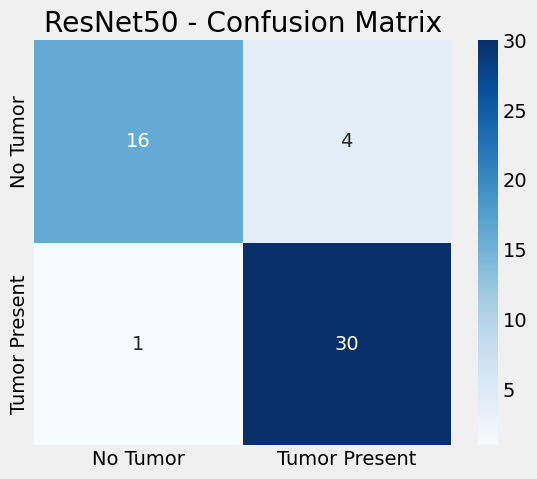

In [13]:
def evaluate_model(model, loader, model_name):
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            y_prob.extend(probs.flatten())
            y_true.extend(labels.numpy())
    
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_score = auc(fpr, tpr)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, AUC: {auc_score:.4f}")
    print(classification_report(y_true, y_pred, target_names=['No Tumor','Tumor Present']))
    
    # Confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Tumor','Tumor Present'],
                yticklabels=['No Tumor','Tumor Present'])
    plt.title(f'{model_name} - Confusion Matrix')
    plt.show()
    
    return {'model_name':model_name, 'accuracy':acc, 'precision':prec, 'recall':rec,
            'f1':f1, 'auc':auc_score, 'fpr':fpr, 'tpr':tpr, 'y_true':y_true, 'y_prob':y_prob}

custom_res = evaluate_model(custom_model, val_loader, "Custom CNN")
vgg_res = evaluate_model(vgg_model, val_loader, "VGG16")
resnet_res = evaluate_model(resnet_model, val_loader, "ResNet50")

## 8. Visualization and ROC Analysis <a id="visualization"></a>

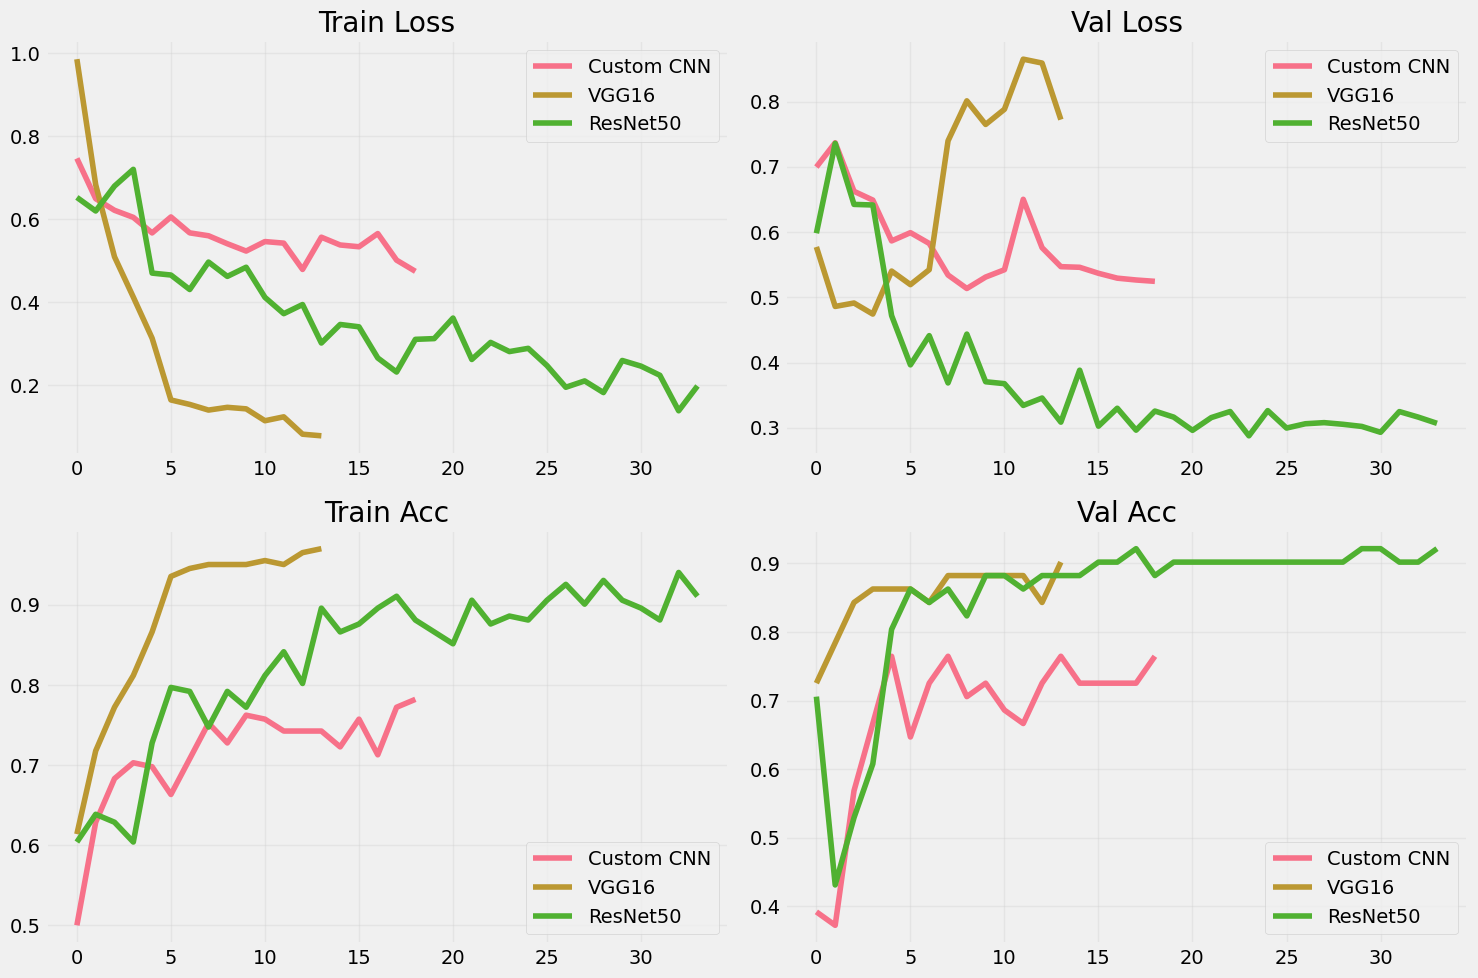

In [14]:
def plot_history(histories, names):
    fig, axes = plt.subplots(2,2,figsize=(15,10))
    metrics = ['train_loss','val_loss','train_acc','val_acc']
    titles = ['Train Loss','Val Loss','Train Acc','Val Acc']
    for idx, (metric, title) in enumerate(zip(metrics, titles)):
        ax = axes[idx//2, idx%2]
        for hist, name in zip(histories, names):
            ax.plot(hist[metric], label=name)
        ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_history([custom_hist, vgg_hist, resnet_hist], ['Custom CNN','VGG16','ResNet50'])

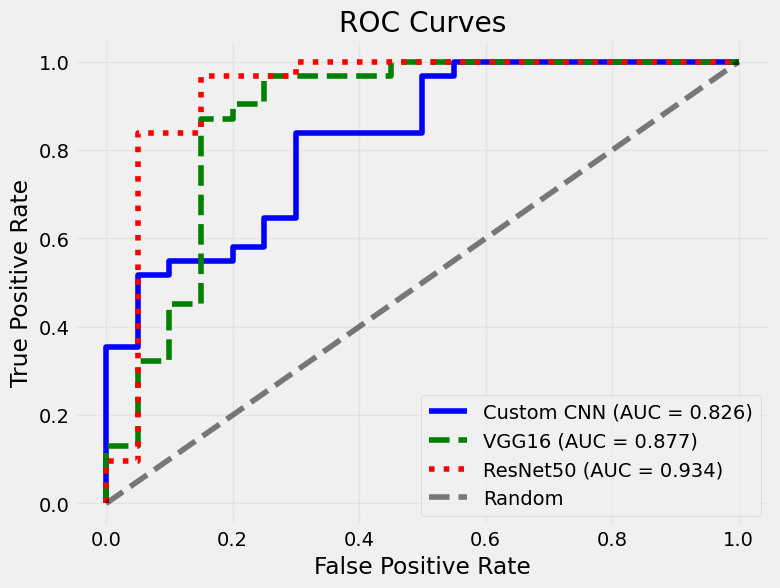

In [15]:
plt.figure(figsize=(8,6))
for res, color, style in zip([custom_res, vgg_res, resnet_res],
                             ['blue','green','red'], ['-','--',':']):
    plt.plot(res['fpr'], res['tpr'], color=color, linestyle=style,
             label=f"{res['model_name']} (AUC = {res['auc']:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.5, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curves'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

     Model Accuracy Precision Recall F1-Score ROC-AUC
Custom CNN   0.7059    0.7222 0.8387   0.7761  0.8258
     VGG16   0.8627    0.8529 0.9355   0.8923  0.8774
  ResNet50   0.9020    0.8824 0.9677   0.9231  0.9339


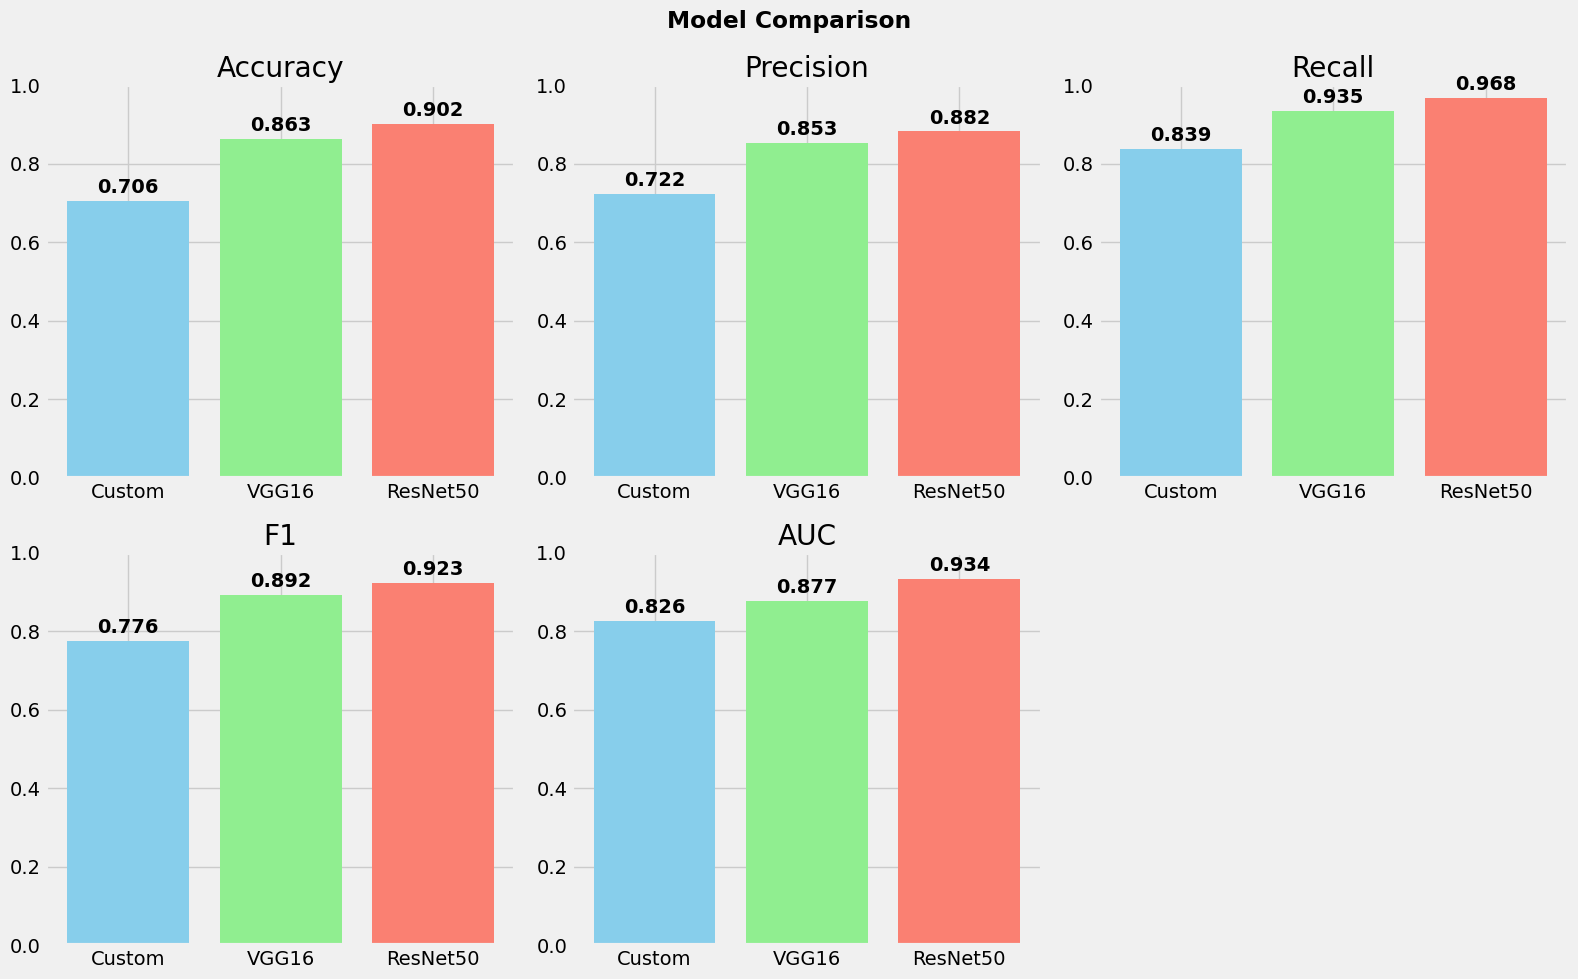

In [16]:
summary = pd.DataFrame([{
    'Model': r['model_name'],
    'Accuracy': f"{r['accuracy']:.4f}",
    'Precision': f"{r['precision']:.4f}",
    'Recall': f"{r['recall']:.4f}",
    'F1-Score': f"{r['f1']:.4f}",
    'ROC-AUC': f"{r['auc']:.4f}"
} for r in [custom_res, vgg_res, resnet_res]])
print(summary.to_string(index=False))

# 柱状图对比
fig, axes = plt.subplots(2,3,figsize=(16,10))
axes = axes.flatten()
metrics = ['accuracy','precision','recall','f1','auc']
titles = ['Accuracy','Precision','Recall','F1','AUC']
for i, (m, t) in enumerate(zip(metrics, titles)):
    vals = [custom_res[m], vgg_res[m], resnet_res[m]]
    axes[i].bar(['Custom','VGG16','ResNet50'], vals, color=['skyblue','lightgreen','salmon'])
    axes[i].set_title(t); axes[i].set_ylim(0,1)
    for j, v in enumerate(vals):
        axes[i].text(j, v+0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[5].remove()
plt.suptitle('Model Comparison', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Model Deployment Preparation <a id="deployment"></a>

Save models in standard PyTorch format and TorchScript for production.

In [17]:
import torch.jit as jit

def export_model(model, name):
    # 保存 weights
    torch.save(model.state_dict(), f'{name}.pt')
    # 导出 TorchScript (通过 tracing)
    model.eval()
    example = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)
    traced = jit.trace(model, example)
    traced.save(f'{name}_scripted.pt')
    print(f"{name} saved.")

export_model(custom_model, 'custom_cnn')
export_model(vgg_model, 'vgg16')
export_model(resnet_model, 'resnet50')

custom_cnn saved.
vgg16 saved.
resnet50 saved.


In [18]:
def predict_image(model, image_path, transform=val_transform):
    image = Image.open(image_path).convert('RGB')
    img_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        logit = model(img_tensor)
        prob = torch.sigmoid(logit).item()
    diagnosis = "Tumor Present" if prob >= 0.5 else "No Tumor"
    print(f"Prediction: {diagnosis} (confidence: {prob:.2%})")
    return prob

# 测试几个样本
for model, name in [(custom_model,'Custom'), (vgg_model,'VGG16'), (resnet_model,'ResNet50')]:
    print(f"\n{name} testing on first validation image:")
    sample_path = val_df.iloc[0]['filepath']
    predict_image(model, sample_path)


Custom testing on first validation image:
Prediction: No Tumor (confidence: 20.98%)

VGG16 testing on first validation image:
Prediction: No Tumor (confidence: 1.48%)

ResNet50 testing on first validation image:
Prediction: No Tumor (confidence: 15.48%)


## 10. Conclusion and Recommendations <a id="conclusion"></a>

### Key Findings

1. **Transfer learning significantly outperforms training from scratch**  
   - Custom CNN (trained from scratch): Accuracy 70.6%, F1 77.6%, AUC 82.6%  
   - VGG16 (transfer learning): Accuracy 86.3%, F1 89.2%, AUC 87.7%  
   - ResNet50 (transfer learning): **Accuracy 90.2%, F1 92.3%, AUC 93.4%** (🏆 Best Model)  
   - On a small dataset of only 253 images, pretrained models provide powerful generic visual features that dramatically reduce overfitting, confirming the indispensability of transfer learning for small-sample medical imaging tasks.

2. **ResNet50 performs exceptionally well on medical images**  
   - ResNet50 achieves a recall of 96.8%, missing only 1 tumor case out of 31 — a critical requirement for clinical screening.  
   - Its residual architecture stabilizes deep network training, allowing it to learn highly discriminative features even with limited data.

3. **The false positive issue can still be improved**  
   - ResNet50’s recall for the “No Tumor” class is 80.0% (4 out of 20 non-tumor cases misclassified as tumor), indicating a tendency toward false positives.  
   - This may result from class imbalance (155 yes vs. 98 no) combined with a slightly aggressive augmentation strategy. Future work could address it by adjusting the classification threshold, applying weighted loss, or using more conservative augmentations.

4. **Evaluation metrics must be aligned with clinical context**  
   - High recall is the top priority (to avoid missed diagnoses), but precision is also important (to reduce unnecessary anxiety and biopsies).  
   - ResNet50 achieves an F1-score of 92.3%, striking a strong balance between the two.

### Limitations

- **Extremely limited dataset size**: The 253 MRI images come from a single source; generalization to other scanners or populations remains unknown.  
- **Binary classification only**: The model cannot distinguish different tumor types (e.g., glioma, meningioma) nor localize the tumor region.  
- **Single train/validation split**: The 80/20 random split may introduce evaluation bias; cross-validation would be more robust for small datasets.  
- **Class imbalance**: The positive-to-negative ratio of approximately 1.58:1 causes the model to slightly favor the majority class (tumor).

### Future Improvements

1. **Multi-class extension**: Incorporate a larger dataset such as the Figshare brain tumor dataset (glioma, meningioma, pituitary) to enable multi-class classification and finer tumor differentiation.  
2. **Tumor segmentation and explainability**: Add a U-Net for tumor segmentation or use Grad-CAM to visualize decision regions, making model outputs more clinically interpretable.  
3. **Data-level augmentation**: Use CycleGAN or traditional augmentation to generate more tumor-free samples and mitigate false positives; adopt medical-imaging-specific augmentations (e.g., random window width/level adjustments).  
4. **Cross-validation and ensembling**: Re-evaluate with 5-fold cross-validation for a more reliable performance estimate, and ensemble predictions from VGG16 and ResNet50 to reduce variance.  
5. **Fine-tune convolutional layers**: Unfreeze the last few residual blocks (e.g., `layer4`) of ResNet50 and fine-tune with a very low learning rate to let the model better adapt to MRI texture details.  
6. **Deployment prototype**: Build a web demo using Streamlit or Gradio where users can upload an MRI scan and receive an instant diagnosis, adding strong presentation value to the project.